In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
from scipy import sparse

# Setup

## Load Data

In [3]:
adata = sc.read("PD_sc/cap_strat_downsample.h5ad",backed='r')

In [4]:
adata

AnnData object with n_obs × n_vars = 438200 × 17266 backed at 'PD_sc/cap_strat_downsample.h5ad'
    obs: 'n_genes', 'n_counts', 'Brain_bank', 'RIN', 'path_braak_lb', 'derived_class2', 'PMI', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid'
    obsm: 'X_umap'

In [6]:
print(adata.obs.columns)          # check metadata columns
print(adata.obs['disease'].value_counts())  # e.g., 'PD' vs 'Control'

Index(['n_genes', 'n_counts', 'Brain_bank', 'RIN', 'path_braak_lb',
       'derived_class2', 'PMI', 'tissue_ontology_term_id', 'tissue_type',
       'assay_ontology_term_id', 'disease_ontology_term_id',
       'cell_type_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')
disease
Parkinson disease    261234
normal               176966
Name: count, dtype: int64


## encode labels

In [8]:
adata.var.columns

Index(['gene_name', 'n_cells', 'feature_is_filtered', 'feature_name',
       'feature_reference', 'feature_biotype', 'feature_length',
       'feature_type'],
      dtype='object')

In [7]:
# Labels are accessible — .obs is loaded into memory
le = LabelEncoder()
y = le.fit_transform(adata.obs['disease'].values)  # 0=Control, 1=PD
print(le.classes_)

['Parkinson disease' 'normal']


## Define compute_metrics

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    r2_score, roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)

def compute_all_metrics(y_true, y_scores, threshold=0.5, model_name='Model'):
    """Compute full suite of metrics for a binary classifier."""
    y_pred = (y_scores >= threshold).astype(int)
    y_scores_clipped = np.clip(y_scores, 0, 1)
    
    metrics = {
        'Model': model_name,
        'AUROC': roc_auc_score(y_true, y_scores),
        'AUPR': average_precision_score(y_true, y_scores),
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Accuracy': (y_pred == y_true).mean(),
        'R²': r2_score(y_true, y_scores_clipped),
        'Threshold': threshold
    }
    return metrics

# Get HVGs

In [46]:
# Compute gene means and variances in chunks
chunk_size = 5000
n_cells = adata.n_obs
n_genes = adata.n_vars

gene_sum = np.zeros(n_genes)
gene_sq_sum = np.zeros(n_genes)

for start in range(0, n_cells, chunk_size):
    end = min(start + chunk_size, n_cells)
    # Read chunk from disk
    chunk = adata.X[start:end]
    if sparse.issparse(chunk):
        chunk = chunk.toarray()
    chunk = np.asarray(chunk, dtype=np.float32)

    gene_sum += chunk.sum(axis=0)
    gene_sq_sum += (chunk ** 2).sum(axis=0)

gene_mean = gene_sum / n_cells
gene_var = (gene_sq_sum / n_cells) - (gene_mean ** 2)

# Select top 2000 most variable genes
n_top_genes = 2000
hvg_indices = np.argsort(gene_var)[-n_top_genes:]
hvg_indices = np.sort(hvg_indices)
gene_names = adata.var_names[hvg_indices]
print(f"Selected {len(hvg_indices)} HVGs by variance")

Selected 2000 HVGs by variance


In [47]:
# Build the full (cells x HVGs) matrix from disk in chunks
chunk_size = 5000
X_list = []

for start in range(0, n_cells, chunk_size):
    end = min(start + chunk_size, n_cells)

    # Slice rows (cells) from disk, then select HVG columns
    chunk = adata.X[start:end]
    if sparse.issparse(chunk):
        chunk = chunk.toarray()
    chunk = np.asarray(chunk, dtype=np.float32)

    # Subset to HVGs
    chunk_hvg = chunk[:, hvg_indices]
    X_list.append(chunk_hvg)

    if start % 50000 == 0:
        print(f"  Loaded {end}/{n_cells} cells...")

X = np.vstack(X_list)
del X_list
print(f"Expression matrix shape: {X.shape}")  # (n_cells, n_hvgs)

  Loaded 5000/438200 cells...
  Loaded 55000/438200 cells...
  Loaded 105000/438200 cells...
  Loaded 155000/438200 cells...
  Loaded 205000/438200 cells...
  Loaded 255000/438200 cells...
  Loaded 305000/438200 cells...
  Loaded 355000/438200 cells...
  Loaded 405000/438200 cells...
Expression matrix shape: (438200, 2000)


# Test/Train Splits

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

del X  # free memory
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (350560, 2000), Test: (87640, 2000)


# Fit Linear Model

In [49]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt

model = LinearRegression(n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Predictions (continuous scores, not bounded to [0,1])
y_scores = model.predict(X_test_scaled)

print(f"Score range: [{y_scores.min():.3f}, {y_scores.max():.3f}]")
print(f"R²: {r2_score(y_test, y_scores):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_scores):.4f}")

Score range: [-0.579, 1.415]
R²: 0.2932
MSE: 0.1702


# GeneFormer v Baseline Comparison

In [52]:
# --- Geneformer metrics ---
gf_metrics = compute_all_metrics(
    merged_df['label'].values,
    merged_df['prob_pd'].values,
    threshold=0.5,
    model_name='Geneformer'
)

# --- OLS metrics ---
# y_scores_ols comes from: model.predict(X_test_scaled)
ols_metrics = compute_all_metrics(
    y_test,
    y_scores,
    threshold=0.5,
    model_name='OLS Linear Regression'
)

# Combine into table
comparison = pd.DataFrame([gf_metrics, ols_metrics]).set_index('Model')
print(comparison.to_string())

                          AUROC      AUPR        F1  Precision    Recall  Accuracy        R²  Threshold
Model                                                                                                  
Geneformer             0.730523  0.900873  0.846522   0.842201  0.850887  0.757005 -0.291911        0.5
OLS Linear Regression  0.827386  0.736363  0.687420   0.705342  0.670387  0.753788  0.301366        0.5


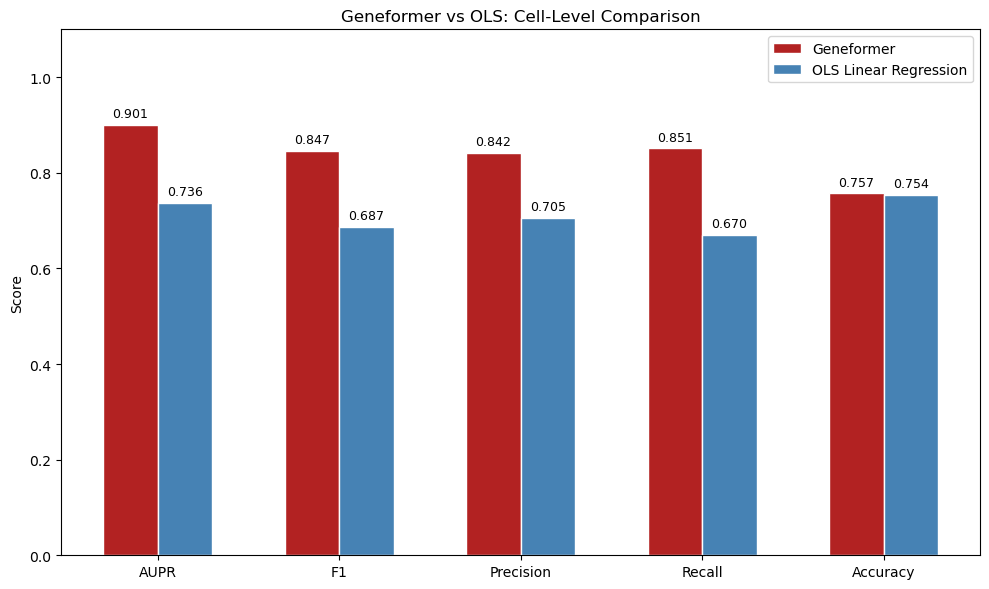

In [74]:
# Only cell-level comparison
gf_metrics = compute_all_metrics(
    merged_df['label'].values,
    merged_df['prob_pd'].values,
    threshold=0.5,
    model_name='Geneformer'
)

ols_metrics = compute_all_metrics(
    y_test,
    y_scores,
    threshold=0.5,
    model_name='OLS Linear Regression'
)

# Bar plot — cell-level only
all_metrics = pd.DataFrame([gf_metrics, ols_metrics]).set_index('Model')

metrics_to_plot = ['AUPR', 'F1', 'Precision', 'Recall', 'Accuracy']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.3

for i, (model, color) in enumerate(zip(all_metrics.index, ['firebrick', 'steelblue'])):
    values = [all_metrics.loc[model, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model, color=color, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Geneformer vs OLS: Cell-Level Comparison')
ax.legend()
plt.tight_layout()
plt.show()

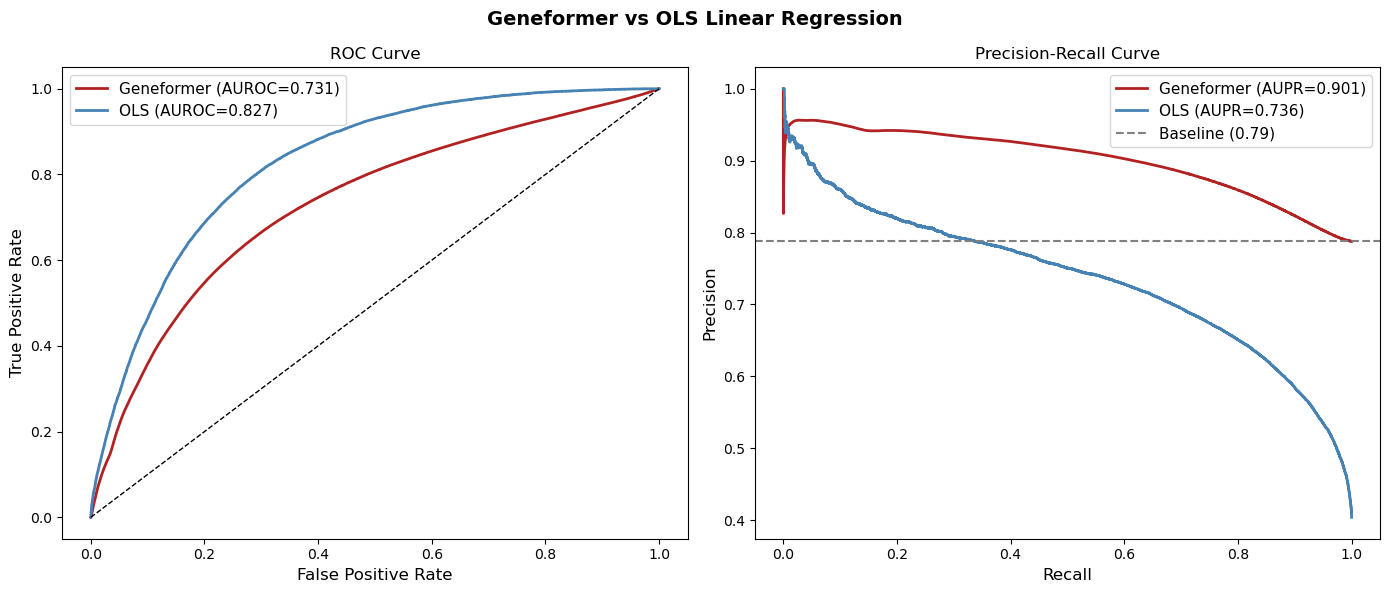

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curve ---
ax = axes[0]
for name, y_true, y_scores, color in [
    ('Geneformer', merged_df['label'].values, merged_df['prob_pd'].values, 'firebrick'),
    ('OLS', y_test, y_scores, 'steelblue')
]:
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUROC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve')
ax.legend(fontsize=11)

# --- PR Curve ---
ax = axes[1]
for name, y_true, y_scores, color in [
    ('Geneformer', merged_df['label'].values, merged_df['prob_pd'].values, 'firebrick'),
    ('OLS', y_test, y_scores, 'steelblue')
]:
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    aupr = average_precision_score(y_true, y_scores)
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUPR={aupr:.3f})')

# Baseline: prevalence
baseline = merged_df['label'].mean()
ax.axhline(baseline, color='grey', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=11)

plt.suptitle('Geneformer vs OLS Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
merged_full.columns

Index(['cell_id', 'donor_id_x', 'cell_type_x', 'fold', 'label', 'pred',
       'prob_pd', 'barcodekey', 'n_genes', 'n_counts', 'Brain_bank', 'RIN',
       'path_braak_lb', 'derived_class2', 'PMI', 'tissue_ontology_term_id',
       'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id',
       'cell_type_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id_y', 'suspension_type', 'is_primary_data', 'cell_type_y',
       'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')

                        cell_type  n_cells  GF_AUROC  GF_AUPR    GF_F1
                   ependymal cell    12559  0.810190 0.944267 0.894062
             glutamatergic neuron    65023  0.762695 0.773666 0.729302
                        astrocyte    66649  0.739975 0.757974 0.728421
                  oligodendrocyte    70429  0.726976 0.737035 0.703184
                 GABAergic neuron    60991  0.724642 0.764685 0.724525
                       mural cell    17865  0.706254 0.878454 0.806796
    central nervous system neuron    18979  0.705968 0.902779 0.812758
                 endothelial cell    11070  0.697586 0.884270 0.815893
central nervous system macrophage    52901  0.692818 0.778302 0.770599
   oligodendrocyte precursor cell    59373  0.681350 0.749877 0.739807
                        leukocyte     2361  0.612741 0.822149 0.733852


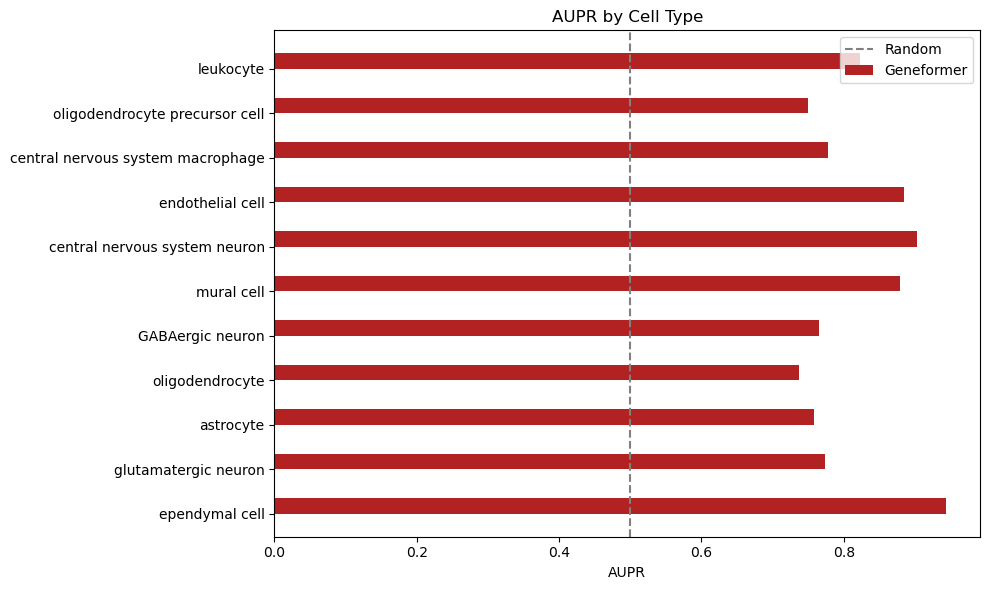

In [62]:
cell_types = merged_full['cell_type_x'].unique()
ct_comparison = []

for ct in sorted(cell_types):
    # Geneformer
    gf_sub = merged_full[merged_full['cell_type_x'] == ct]
    if gf_sub['label'].nunique() < 2:
        continue
    
    gf_auroc = roc_auc_score(gf_sub['label'], gf_sub['prob_pd'])
    gf_aupr = average_precision_score(gf_sub['label'], gf_sub['prob_pd'])
    gf_f1 = f1_score(gf_sub['label'], (gf_sub['prob_pd'] >= 0.5).astype(int))
    
    # OLS — you need cell_type info attached to OLS predictions
    # Adjust this based on your OLS results dataframe
    # ols_sub = ols_results[ols_results['cell_type'] == ct]
    # ols_auroc = roc_auc_score(ols_sub['label'], ols_sub['prob_ols'])
    
    ct_comparison.append({
        'cell_type': ct,
        'n_cells': len(gf_sub),
        'GF_AUROC': gf_auroc,
        'GF_AUPR': gf_aupr,
        'GF_F1': gf_f1,
        # 'OLS_AUROC': ols_auroc,  # uncomment when OLS results available
    })

ct_df = pd.DataFrame(ct_comparison).sort_values('GF_AUROC', ascending=False)
print(ct_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(ct_df) * 0.4)))
y_pos = np.arange(len(ct_df))
width = 0.35

ax.barh(y_pos + width/2, ct_df['GF_AUPR'], width, label='Geneformer', color='firebrick')
# ax.barh(y_pos - width/2, ct_df['OLS_AUROC'], width, label='OLS', color='steelblue')

ax.set_yticks(y_pos)
ax.set_yticklabels(ct_df['cell_type'])
ax.set_xlabel('AUPR')
ax.set_title('AUPR by Cell Type')
ax.axvline(0.5, color='grey', linestyle='--', label='Random')
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
# Final clean comparison table
summary = pd.DataFrame([gf_metrics, ols_metrics]).set_index('Model')
summary = summary[['AUROC', 'AUPR', 'F1', 'Precision', 'Recall', 'Accuracy', 'R²']]
summary = summary.round(4)

print("\n" + "=" * 70)
print("  CELL-LEVEL COMPARISON: Geneformer vs OLS Baseline")
print("=" * 70)
print(summary.to_string())

# Improvement
print("\n--- Geneformer improvement over OLS ---")
for col in summary.columns:
    diff = summary.loc['Geneformer', col] - summary.loc['OLS Linear Regression', col]
    print(f"  {col}: {diff:+.4f}")


  CELL-LEVEL COMPARISON: Geneformer vs OLS Baseline
                        AUROC    AUPR      F1  Precision  Recall  Accuracy      R²
Model                                                                             
Geneformer             0.7305  0.9009  0.8465     0.8422  0.8509    0.7570 -0.2919
OLS Linear Regression  0.8274  0.7364  0.6874     0.7053  0.6704    0.7538  0.3014

--- Geneformer improvement over OLS ---
  AUROC: -0.0969
  AUPR: +0.1645
  F1: +0.1591
  Precision: +0.1369
  Recall: +0.1805
  Accuracy: +0.0032
  R²: -0.5933


# Baseline Visualization

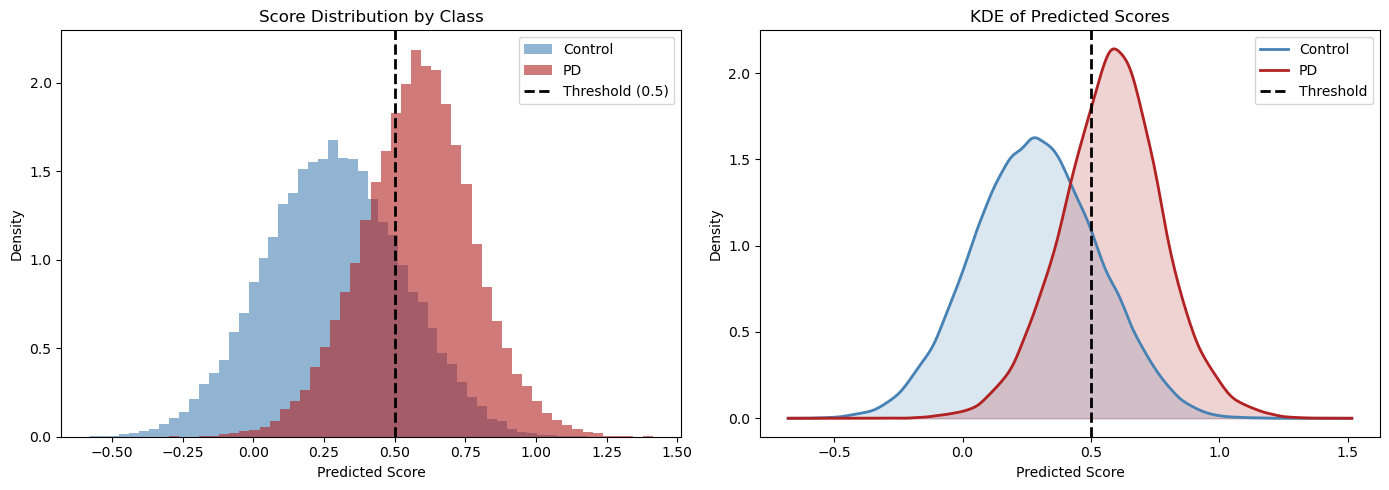

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_scores[y_test == 0], bins=50, alpha=0.6, label='Control', color='steelblue', density=True)
axes[0].hist(y_scores[y_test == 1], bins=50, alpha=0.6, label='PD', color='firebrick', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Class')
axes[0].legend()

# KDE (smoother view)
from scipy.stats import gaussian_kde

scores_ctrl = y_scores[y_test == 0]
scores_pd = y_scores[y_test == 1]

x_range = np.linspace(y_scores.min() - 0.1, y_scores.max() + 0.1, 300)
kde_ctrl = gaussian_kde(scores_ctrl)
kde_pd = gaussian_kde(scores_pd)

axes[1].plot(x_range, kde_ctrl(x_range), color='steelblue', linewidth=2, label='Control')
axes[1].plot(x_range, kde_pd(x_range), color='firebrick', linewidth=2, label='PD')
axes[1].fill_between(x_range, kde_ctrl(x_range), alpha=0.2, color='steelblue')
axes[1].fill_between(x_range, kde_pd(x_range), alpha=0.2, color='firebrick')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of Predicted Scores')
axes[1].legend()

plt.tight_layout()
plt.show()

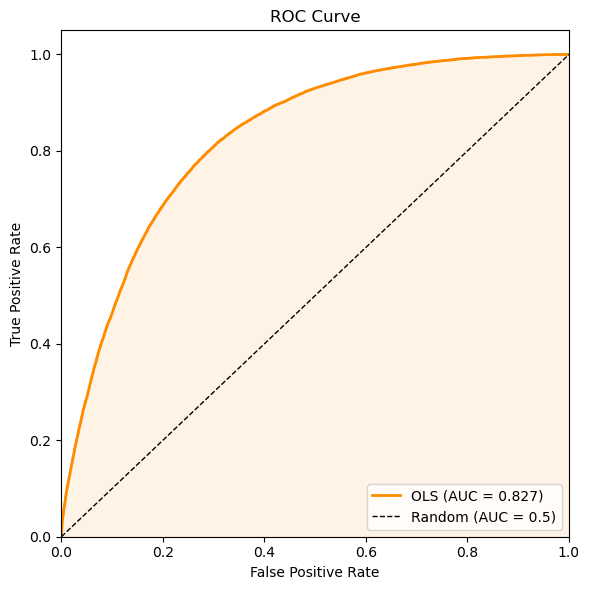

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'OLS (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

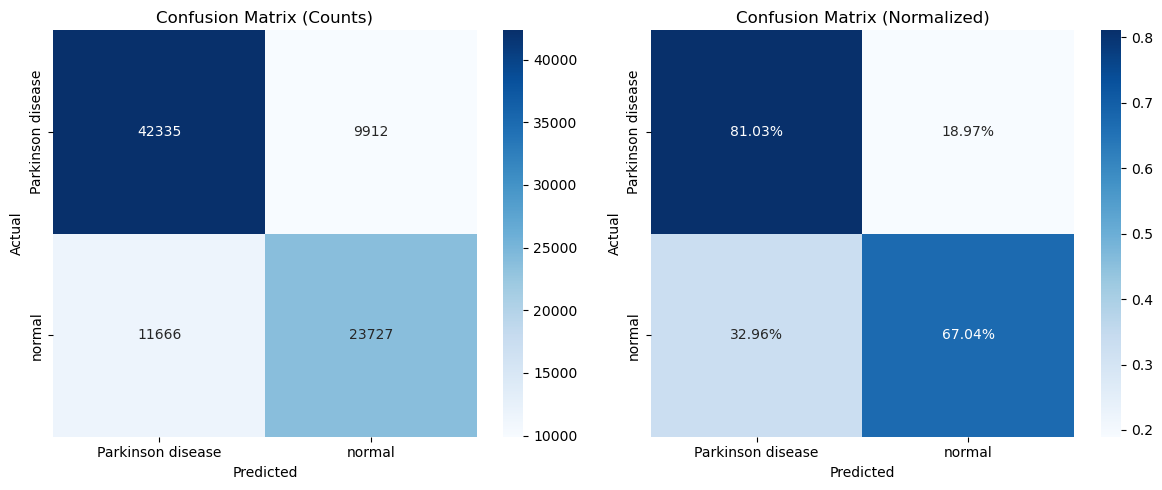

In [19]:
import seaborn as sns

y_pred = (y_scores >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized by row (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

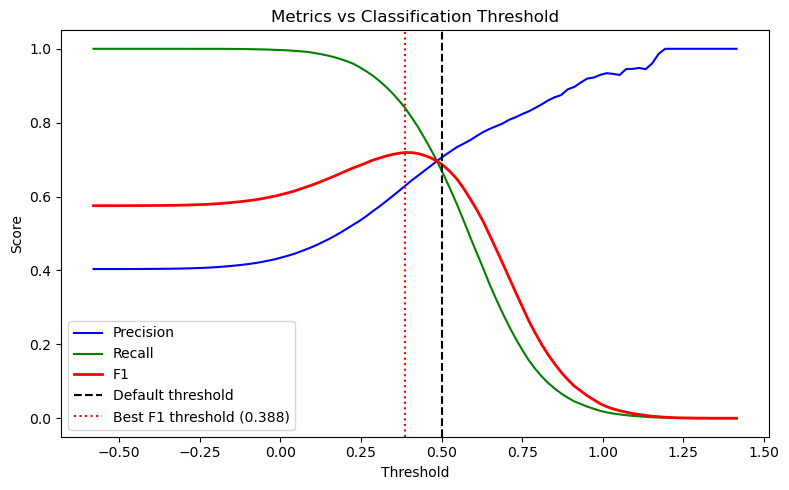

Best threshold by F1: 0.388
Best F1: 0.719


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_sweep = np.linspace(y_scores.min(), y_scores.max(), 100)
precisions = []
recalls = []
f1s = []

for t in thresholds_sweep:
    preds = (y_scores >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds_sweep, precisions, label='Precision', color='blue')
ax.plot(thresholds_sweep, recalls, label='Recall', color='green')
ax.plot(thresholds_sweep, f1s, label='F1', color='red', linewidth=2)
ax.axvline(0.5, color='black', linestyle='--', label='Default threshold')

best_t = thresholds_sweep[np.argmax(f1s)]
ax.axvline(best_t, color='red', linestyle=':', label=f'Best F1 threshold ({best_t:.3f})')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold by F1: {best_t:.3f}")
print(f"Best F1: {max(f1s):.3f}")

# GeneFormer Training Results

In [10]:
import pandas as pd

# Read and concatenate all folds
dfs = []
for fold in range(5):
    df = pd.read_csv(f'test_predictions/fold{fold}_test_pred.csv')
    dfs.append(df)

# Merge all folds
merged_df = pd.concat(dfs, ignore_index=True)
print(merged_df.head())
print(f"Shape: {merged_df.shape}")

                     cell_id donor_id                          cell_type  \
0  Set11_C1-AAACCCAAGACGGTTG   CASE_4               glutamatergic neuron   
1  Set11_C1-AAACCCAAGGATTCAA   CASE_4  central nervous system macrophage   
2  Set11_C1-AAACCCACACAACGAG   CASE_4                    oligodendrocyte   
3  Set11_C1-AAACCCAGTCCGACGT   CASE_4               glutamatergic neuron   
4  Set11_C1-AAACCCATCCGTGTGG   CASE_4               glutamatergic neuron   

   fold  label  pred   prob_pd  
0     0      1     0  0.000286  
1     0      1     1  0.992555  
2     0      1     1  0.999680  
3     0      1     1  0.999872  
4     0      1     1  0.996833  
Shape: (2096155, 7)


Control cells: 445,297
PD cells: 1,650,858


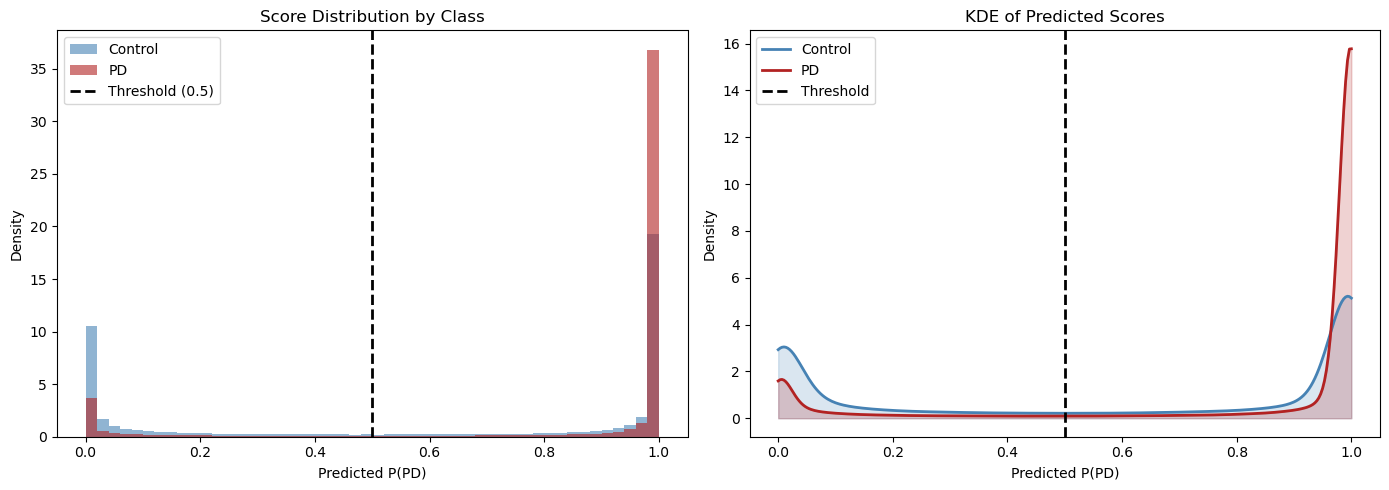

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Separate scores by class
scores_ctrl = merged_df.loc[merged_df['label'] == 0, 'prob_pd'].values
scores_pd = merged_df.loc[merged_df['label'] == 1, 'prob_pd'].values

print(f"Control cells: {len(scores_ctrl):,}")
print(f"PD cells: {len(scores_pd):,}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(scores_ctrl, bins=50, alpha=0.6, label='Control', color='steelblue', density=True)
axes[0].hist(scores_pd, bins=50, alpha=0.6, label='PD', color='firebrick', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].set_xlabel('Predicted P(PD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Class')
axes[0].legend()

# KDE (smoother view)
x_range = np.linspace(0, 1, 300)
kde_ctrl = gaussian_kde(scores_ctrl)
kde_pd = gaussian_kde(scores_pd)

axes[1].plot(x_range, kde_ctrl(x_range), color='steelblue', linewidth=2, label='Control')
axes[1].plot(x_range, kde_pd(x_range), color='firebrick', linewidth=2, label='PD')
axes[1].fill_between(x_range, kde_ctrl(x_range), alpha=0.2, color='steelblue')
axes[1].fill_between(x_range, kde_pd(x_range), alpha=0.2, color='firebrick')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Predicted P(PD)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of Predicted Scores')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import r2_score

r2 = r2_score(merged_df['label'], merged_df['prob_pd'])
print(f"R² = {r2:.4f}")

R² = -0.2919


/tmp/ipykernel_1567355/2700482230.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/coja/miniconda/envs/scanpy/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


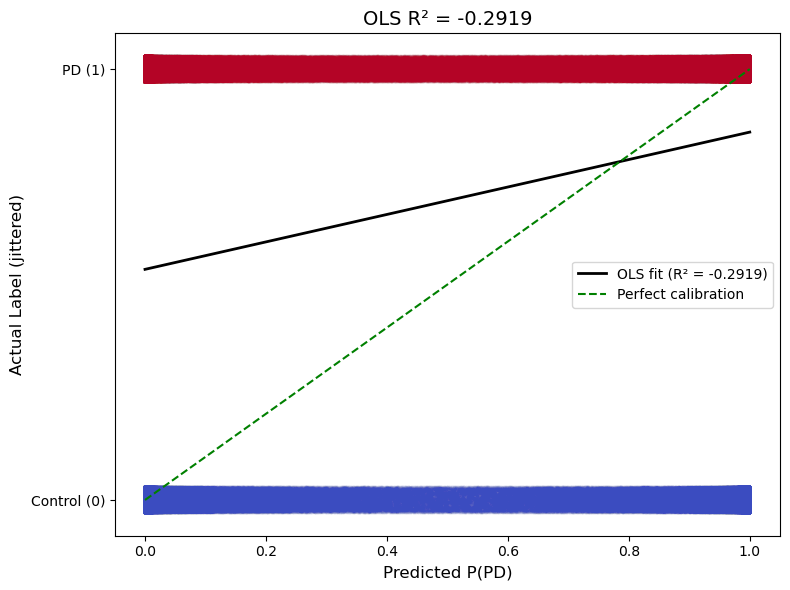

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

r2 = r2_score(merged_df['label'], merged_df['prob_pd'])

fig, ax = plt.subplots(figsize=(8, 6))

# Jitter actual labels for visibility (since they're just 0 and 1)
jitter = np.random.uniform(-0.03, 0.03, size=len(merged_df))
y_jittered = merged_df['label'].values + jitter

ax.scatter(merged_df['prob_pd'], y_jittered,
           c=merged_df['label'], cmap='coolwarm',
           alpha=0.02, s=3)

# OLS regression line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(merged_df['prob_pd'], merged_df['label'], 1)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, b + m * x_line, color='black', linewidth=2, label=f'OLS fit (R² = {r2:.4f})')

# Perfect prediction line
ax.plot([0, 1], [0, 1], 'g--', linewidth=1.5, label='Perfect calibration')

ax.set_xlabel('Predicted P(PD)', fontsize=12)
ax.set_ylabel('Actual Label (jittered)', fontsize=12)
ax.set_title(f'OLS R² = {r2:.4f}', fontsize=14)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control (0)', 'PD (1)'])
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Overall class balance
print(f"Overall PD fraction: {merged_df['label'].mean():.3f}")
print(f"Overall R²: {r2_score(merged_df['label'], merged_df['prob_pd']):.4f}")
print(f"Overall AUC: {roc_auc_score(merged_df['label'], merged_df['prob_pd']):.4f}")
print()

# Per cell type balance and R²
for ct in sorted(merged_df['cell_type'].unique()):
    subset = merged_df[merged_df['cell_type'] == ct]
    if subset['label'].nunique() < 2:
        continue
    pd_frac = subset['label'].mean()
    r2_ct = r2_score(subset['label'], subset['prob_pd'])
    auc_ct = roc_auc_score(subset['label'], subset['prob_pd'])
    print(f"{ct:40s} | PD%={pd_frac:.2f} | R²={r2_ct:+.4f} | AUC={auc_ct:.4f} | n={len(subset):,}")

Overall PD fraction: 0.788
Overall R²: -0.2919
Overall AUC: 0.7305

GABAergic neuron                         | PD%=0.77 | R²=-0.2929 | AUC=0.7236 | n=152,393
astrocyte                                | PD%=0.82 | R²=-0.2544 | AUC=0.7667 | n=227,452
central nervous system macrophage        | PD%=0.81 | R²=-0.3608 | AUC=0.7056 | n=118,515
central nervous system neuron            | PD%=0.79 | R²=-0.5005 | AUC=0.7060 | n=18,979
endothelial cell                         | PD%=0.78 | R²=-0.3057 | AUC=0.6976 | n=11,070
ependymal cell                           | PD%=0.84 | R²=-0.0868 | AUC=0.8102 | n=12,559
glutamatergic neuron                     | PD%=0.76 | R²=-0.2247 | AUC=0.7525 | n=328,856
leukocyte                                | PD%=0.73 | R²=-0.3930 | AUC=0.6127 | n=2,361
mural cell                               | PD%=0.76 | R²=-0.2533 | AUC=0.7063 | n=17,865
oligodendrocyte                          | PD%=0.79 | R²=-0.3101 | AUC=0.7296 | n=1,093,520
oligodendrocyte precursor cell      

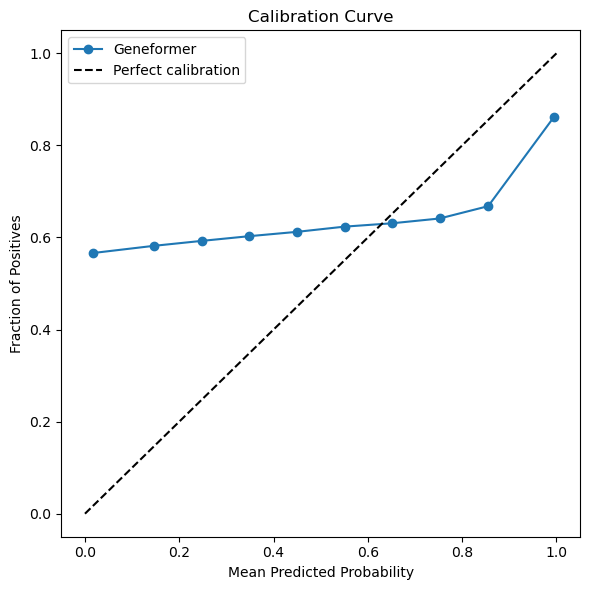

In [18]:
from sklearn.calibration import calibration_curve

# Check calibration
prob_true, prob_pred = calibration_curve(
    merged_df['label'], merged_df['prob_pd'], n_bins=10
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, 'o-', label='Geneformer')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

   donor_id  mean_prob_pd  median_prob_pd  label  n_cells
0    CASE_1      0.966054        0.999960      1    31375
1   CASE_10      0.940346        0.999892      1    28211
2   CASE_11      0.989605        0.999865      1    20716
3   CASE_12      0.898304        0.999945      1    24881
4   CASE_13      0.968990        0.999441      1    31534
..      ...           ...             ...    ...      ...
92   CTRL_5      0.650332        0.873001      0    20540
93   CTRL_6      0.924570        0.999127      0    23512
94   CTRL_7      0.309937        0.062673      0    18706
95   CTRL_8      0.529823        0.650499      0    28511
96   CTRL_9      0.734947        0.993361      0    37638

[97 rows x 5 columns]

Donor-level R²: 0.2017
Donor-level AUC: 0.8179


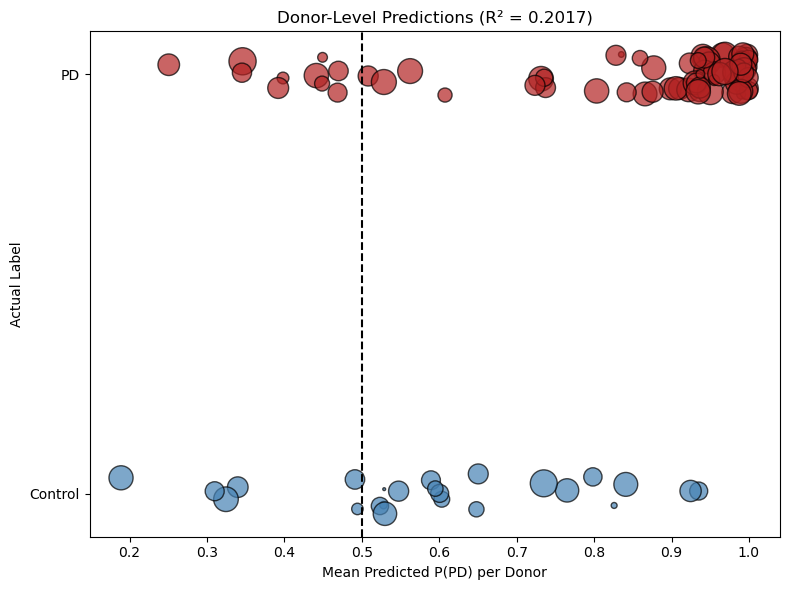

In [19]:
# Aggregate to donor level (mean probability per donor)
donor_agg = merged_df.groupby('donor_id').agg(
    mean_prob_pd=('prob_pd', 'mean'),
    median_prob_pd=('prob_pd', 'median'),
    label=('label', 'first'),
    n_cells=('label', 'size')
).reset_index()

print(donor_agg)

# Now compute R² at donor level
r2_donor_level = r2_score(donor_agg['label'], donor_agg['mean_prob_pd'])
print(f"\nDonor-level R²: {r2_donor_level:.4f}")
print(f"Donor-level AUC: {roc_auc_score(donor_agg['label'], donor_agg['mean_prob_pd']):.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['firebrick' if l == 1 else 'steelblue' for l in donor_agg['label']]
ax.scatter(donor_agg['mean_prob_pd'],
           donor_agg['label'] + np.random.uniform(-0.05, 0.05, size=len(donor_agg)),
           c=colors, s=donor_agg['n_cells'] / 100, alpha=0.7, edgecolors='black')
ax.axvline(0.5, color='black', linestyle='--')
ax.set_xlabel('Mean Predicted P(PD) per Donor')
ax.set_ylabel('Actual Label')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'PD'])
ax.set_title(f'Donor-Level Predictions (R² = {r2_donor_level:.4f})')
plt.tight_layout()
plt.show()

In [36]:
# Reset meta index to make it a column, then merge
merged_full = merged_df.merge(
    meta.reset_index(),
    left_on='cell_id',
    right_on='barcodekey')

print(f"Before merge: {merged_df.shape}")
print(f"After merge: {merged_full.shape}")
print(f"Null values from meta: {merged_full['path_braak_lb'].isna().sum()}")

Before merge: (2096155, 7)
After merge: (438200, 34)
Null values from meta: 0


In [37]:
merged_full.head()

,cell_id,donor_id_x,cell_type_x,fold,label,pred,prob_pd,barcodekey,n_genes,n_counts,...,suspension_type,is_primary_data,cell_type_y,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
0,Set11_C1-AAACGAAGTAGGCAAC,CASE_4,oligodendrocyte,0,1,1,0.891973,Set11_C1-AAACGAAGTAGGCAAC,2228,4179.0,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,prefrontal cortex,unknown,102-year-old stage,V=wDNq+eTq
1,Set11_C1-AAAGAACTCGTAGCTA,CASE_4,glutamatergic neuron,0,1,1,0.640699,Set11_C1-AAAGAACTCGTAGCTA,6208,25417.0,...,nucleus,True,glutamatergic neuron,10x 3' v3,Parkinson disease,male,prefrontal cortex,unknown,102-year-old stage,<50fUO)hBP
2,Set11_C1-AAAGGATAGCGATGAC,CASE_4,oligodendrocyte precursor cell,0,1,1,0.990616,Set11_C1-AAAGGATAGCGATGAC,3278,6998.0,...,nucleus,True,oligodendrocyte precursor cell,10x 3' v3,Parkinson disease,male,prefrontal cortex,unknown,102-year-old stage,(N5YK^_#D4
3,Set11_C1-AAAGGATAGTGTACCT,CASE_4,glutamatergic neuron,0,1,0,0.023049,Set11_C1-AAAGGATAGTGTACCT,6158,16832.0,...,nucleus,True,glutamatergic neuron,10x 3' v3,Parkinson disease,male,prefrontal cortex,unknown,102-year-old stage,>EL#SPQ9$&
4,Set11_C1-AAAGGGCTCGAAGCAG,CASE_4,glutamatergic neuron,0,1,1,0.987420,Set11_C1-AAAGGGCTCGAAGCAG,5785,21333.0,...,nucleus,True,glutamatergic neuron,10x 3' v3,Parkinson disease,male,prefrontal cortex,unknown,102-year-old stage,!%{Ni$+9RI


In [41]:
# Aggregate to donor level with Braak stage
donor_agg = merged_full.groupby('donor_id_x').agg(
    mean_prob_pd=('prob_pd', 'mean'),
    label=('label', 'first'),
    braak=('path_braak_lb', 'first'),
    n_cells=('label', 'size')
).reset_index()

print(donor_agg)

   donor_id_x  mean_prob_pd  label  braak  n_cells
0      CASE_1      0.924413      1      3     3449
1     CASE_10      0.888138      1      5     4465
2     CASE_11      0.979677      1      6     3810
3     CASE_12      0.843289      1      5     3599
4     CASE_13      0.959604      1      4     3910
..        ...           ...    ...    ...      ...
92     CTRL_5      0.619225      0      1     9225
93     CTRL_6      0.906478      0      0    10481
94     CTRL_7      0.304835      0      0     8333
95     CTRL_8      0.449357      0      0    10086
96     CTRL_9      0.707269      0      0     9278

[97 rows x 5 columns]


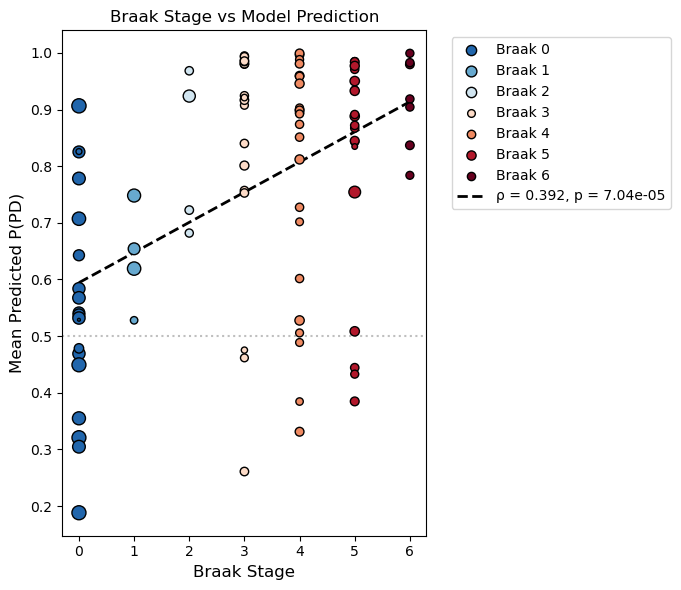

In [43]:
from scipy.stats import spearmanr
braak_colors = {
    0: '#2166ac',  # blue (no pathology)
    1: '#67a9cf',
    2: '#d1e5f0',
    3: '#fddbc7',
    4: '#ef8a62',
    5: '#b2182b',  # dark red (severe)
    6: '#67001f'
}
corr, pval = spearmanr(donor_agg['braak'], donor_agg['mean_prob_pd'])

fig, ax = plt.subplots(figsize=(7, 6))

for braak in sorted(donor_agg['braak'].unique()):
    subset = donor_agg[donor_agg['braak'] == braak]
    ax.scatter(
        subset['braak'],
        subset['mean_prob_pd'],
        c=braak_colors.get(braak, 'grey'),
        s=subset['n_cells'] / 100,
        edgecolors='black',
        label=f'Braak {braak}',
        zorder=3
    )

# Trend line
z = np.polyfit(donor_agg['braak'], donor_agg['mean_prob_pd'], 1)
p = np.poly1d(z)
x_line = np.linspace(donor_agg['braak'].min(), donor_agg['braak'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2,
        label=f'ρ = {corr:.3f}, p = {pval:.2e}')

ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5)
ax.set_xlabel('Braak Stage', fontsize=12)
ax.set_ylabel('Mean Predicted P(PD)', fontsize=12)
ax.set_title('Braak Stage vs Model Prediction')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

   donor_id_x  mean_prob_pd  median_prob_pd  label  braak  n_cells
0      CASE_1      0.924413        0.999746      1      3     3449
1     CASE_10      0.888138        0.998798      1      5     4465
2     CASE_11      0.979677        0.999784      1      6     3810
3     CASE_12      0.843289        0.999616      1      5     3599
4     CASE_13      0.959604        0.998909      1      4     3910
..        ...           ...             ...    ...    ...      ...
92     CTRL_5      0.619225        0.787179      0      1     9225
93     CTRL_6      0.906478        0.997459      0      0    10481
94     CTRL_7      0.304835        0.074060      0      0     8333
95     CTRL_8      0.449357        0.273140      0      0    10086
96     CTRL_9      0.707269        0.984565      0      0     9278

[97 rows x 6 columns]

Donor-level R²: 0.2202
Donor-level AUC: 0.8116


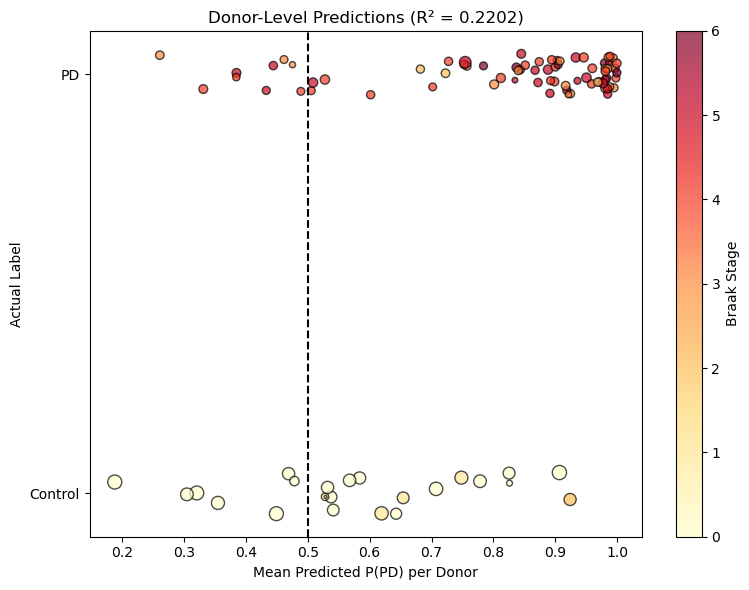

In [45]:
# Aggregate to donor level (add braak stage)
donor_agg = merged_full.groupby('donor_id_x').agg(
    mean_prob_pd=('prob_pd', 'mean'),
    median_prob_pd=('prob_pd', 'median'),
    label=('label', 'first'),
    braak=('path_braak_lb', 'first'),
    n_cells=('label', 'size')
).reset_index()

print(donor_agg)

# Compute R² at donor level
r2_donor_level = r2_score(donor_agg['label'], donor_agg['mean_prob_pd'])
print(f"\nDonor-level R²: {r2_donor_level:.4f}")
print(f"Donor-level AUC: {roc_auc_score(donor_agg['label'], donor_agg['mean_prob_pd']):.4f}")

# Visualize — only change is color mapping
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    donor_agg['mean_prob_pd'],
    donor_agg['label'] + np.random.uniform(-0.05, 0.05, size=len(donor_agg)),
    c=donor_agg['braak'],
    cmap='YlOrRd',
    s=donor_agg['n_cells'] / 100,
    alpha=0.7,
    edgecolors='black'
)

ax.axvline(0.5, color='black', linestyle='--')
ax.set_xlabel('Mean Predicted P(PD) per Donor')
ax.set_ylabel('Actual Label')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'PD'])
ax.set_title(f'Donor-Level Predictions (R² = {r2_donor_level:.4f})')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Braak Stage')

plt.tight_layout()
plt.show()